## Grid Creation (Always Solvable as in LinkedIn)

In [3]:
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
from matplotlib import colors
import time
import math
import statistics
from statistics import mean, median, mode

In [5]:
def set_global_seed(seed=42):
    """
    Set the seed for all random sources used in this notebook
    (Python's random and NumPy).
    """
    random.seed(seed)
    np.random.seed(seed)

set_global_seed(42)

In [6]:
def generate_solvable_grid_from_solution(grid_size=None, n_regions=None, max_attempts=1000):
    """
    Generate an N x N grid with N connected regions, each of which contains exactly 1 queen.
    Returns:
        grid: (grid_size x grid_size) numpy array of region IDs in [1..n_regions]
        solution: list of length grid_size where solution[row] = col of queen
    """

    # Defaults: classic LinkedIn case = 8x8 with 8 regions
    if grid_size is None:
        grid_size = 8
    if n_regions is None:
        n_regions = grid_size

    # We require exactly one queen per region and one region per queen
    assert grid_size == n_regions, "For this generator, n_regions must equal grid_size."

    def has_adjacent_queens(cols):
        # Check adjacency between queens
        for r1 in range(grid_size):
            for r2 in range(r1 + 1, grid_size):
                if abs(r1 - r2) <= 1 and abs(cols[r1] - cols[r2]) <= 1:
                    return True
        return False

    for _ in range(max_attempts):
        # random permutation of columns: one queen per row and per column
        cols = random.sample(range(grid_size), grid_size)
        if has_adjacent_queens(cols):
            continue

        # Found a valid queen layout
        solution = cols[:]
        grid = np.zeros((grid_size, grid_size), dtype=int)

        # Use each queen as a seed for one region
        seeds = [(r, solution[r]) for r in range(grid_size)]
        for region_id, (r, c) in enumerate(seeds, start=1):
            grid[r, c] = region_id

        frontiers = {region_id: deque([seed]) for region_id, seed in enumerate(seeds, start=1)}

        def neighbors(r, c):
            for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                nr, nc = r + dr, c + dc
                if 0 <= nr < grid_size and 0 <= nc < grid_size:
                    yield nr, nc

        # Expand regions until full
        unassigned = grid_size * grid_size - n_regions
        while unassigned > 0:
            progress = False
            # randomize order of regions each sweep
            for region_id in random.sample(range(1, n_regions + 1), n_regions):
                if not frontiers[region_id]:
                    continue
                r, c = frontiers[region_id].popleft()
                candidates = [(nr, nc) for nr, nc in neighbors(r, c) if grid[nr, nc] == 0]
                random.shuffle(candidates)
                if candidates:
                    nr, nc = candidates[0]
                    grid[nr, nc] = region_id
                    frontiers[region_id].append((nr, nc))
                    unassigned -= 1
                    progress = True
                # if this cell still has empty neighbors, keep it in frontier
                if any(grid[nr, nc] == 0 for nr, nc in neighbors(r, c)):
                    frontiers[region_id].append((r, c))

            if not progress:
                # Fill any leftover cells by expanding neighboring regions
                remaining = [(r, c) for r in range(grid_size)
                             for c in range(grid_size) if grid[r, c] == 0]
                for r, c in remaining:
                    for nr, nc in neighbors(r, c):
                        if grid[nr, nc] != 0:
                            grid[r, c] = grid[nr, nc]
                            unassigned -= 1
                            break
                break

        return grid, solution

    raise RuntimeError("Could not create a valid grid after multiple attempts.")


## Grid Visualization

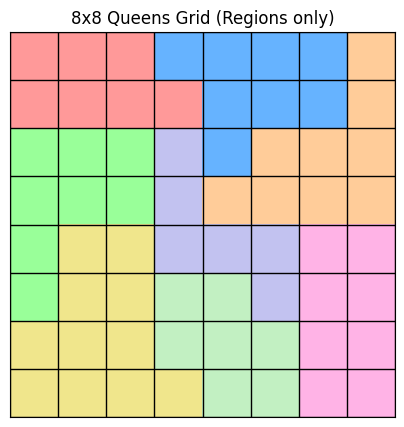

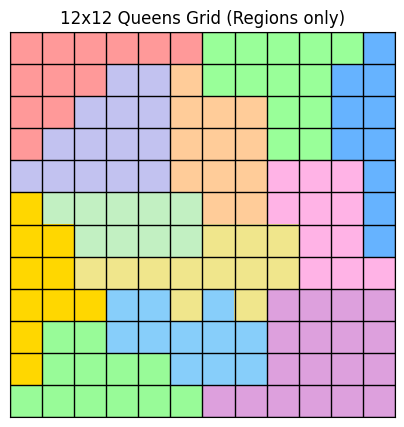

Region Grids (No Queens Displayed)


In [7]:
region_colors_15 = [
    '#ff9999',
    '#66b3ff',
    '#99ff99',
    '#ffcc99',
    '#c2c2f0',
    '#ffb3e6',
    '#c2f0c2',
    '#f0e68c',
    '#ffd700',
    '#87cefa',
    '#dda0dd',
    '#98fb98',
    '#ffa07a',
    '#afeeee',
    '#e6e6fa',
]

def get_region_cmap(grid):
    n_regions = int(grid.max())
    if n_regions > len(region_colors_15):
        raise ValueError(f"Need more colors: n_regions={n_regions}, only {len(region_colors_15)} defined.")
    return colors.ListedColormap(region_colors_15[:n_regions])

def visualize_grid_borders(grid, title=None):
    cmap = get_region_cmap(grid)
    n = grid.shape[0]
    if title is None:
        title = f"{n}x{n} Queens Grid (Regions only)"

    plt.figure(figsize=(5, 5))
    plt.imshow(grid, cmap=cmap, origin='upper')

    for i in range(n + 1):
        plt.axhline(i - 0.5, color='black', linewidth=1)
        plt.axvline(i - 0.5, color='black', linewidth=1)

    plt.title(title)
    plt.xticks([]); plt.yticks([])
    plt.show()


def visualize_solution_on_grid(grid, solution, title=None):
    cmap = get_region_cmap(grid)
    n = grid.shape[0]
    if title is None:
        title = f"Solved {n}x{n} Queens Grid (Queens shown)"

    plt.figure(figsize=(5, 5))
    plt.imshow(grid, cmap=cmap, origin='upper')

    for i in range(n + 1):
        plt.axhline(i - 0.5, color='black', linewidth=1)
        plt.axvline(i - 0.5, color='black', linewidth=1)

    if solution:
        for r, c in enumerate(solution):
            plt.text(c, r, "♛", fontsize=20, ha='center', va='center', color='black')

    plt.title(title)
    plt.xticks([]); plt.yticks([])
    plt.show()


grid8, true_solution8 = generate_solvable_grid_from_solution(grid_size=8, n_regions=8)
grid12, true_solution12 = generate_solvable_grid_from_solution(grid_size=12, n_regions=12)

visualize_grid_borders(grid8)
visualize_grid_borders(grid12)

print("Region Grids (No Queens Displayed)")

# Later, after solving:
# visualize_solution_on_grid(grid8, found_solution8)
# visualize_solution_on_grid(grid12, found_solution12)


## Implementing a Solution using Backtracking Search

**Our variables here are the rows (from 0 to 7), and for them we choose a column to place a queen.**
    
The following constraints should hold:
- one queen per row
- no two queens in the same column
- no two queens in the same region

In [8]:
def solve_queens_by_row_backtracking(grid):
    """
    Simple depth-first backtracking solver.

    Variables: rows 0..n-1
    Values:    columns 0..n-1

    Constraints:
        - One queen per row (by construction)
        - No two queens in the same column
        - No two queens in the same region
        - No two queens in adjacent cells (including diagonals)
    """
    n = grid.shape[0]

    used_columns = set()
    used_regions = set()
    assignment = {}

    def is_consistent(row, col):
        if col in used_columns:
            return False

        region = int(grid[row, col])
        if region in used_regions:
            return False

        for other_row, other_col in assignment.items():
            if abs(other_row - row) <= 1 and abs(other_col - col) <= 1:
                return False

        return True

    def backtrack(row_index=0):
        if row_index == n:
            return [assignment[r] for r in range(n)]

        for col in range(n):
            if not is_consistent(row_index, col):
                continue

            assignment[row_index] = col
            used_columns.add(col)
            region = int(grid[row_index, col])
            used_regions.add(region)

            result = backtrack(row_index + 1)
            if result is not None:
                return result

            del assignment[row_index]
            used_columns.remove(col)
            used_regions.remove(region)

        return None

    return backtrack(0)


## MAC-style solver (backtracking + Forward Checking + optional AC-3)

In [9]:
def solve_queens_backtracking_fc_ac3(grid, use_ac3=True):

    n = grid.shape[0]

    # Constraint checks

    def compatible_positions(r1, c1, r2, c2):
        if c1 == c2:
            return False
        if int(grid[r1, c1]) == int(grid[r2, c2]):
            return False
        if abs(r1 - r2) <= 1 and abs(c1 - c2) <= 1:
            return False
        return True

    def is_consistent_with_assignment(row, col, assignment):
        for r2, c2 in assignment.items():
            if not compatible_positions(row, col, r2, c2):
                return False
        return True

    # Forward Checking

    def forward_check(domains, assignment, row, col):
        region = int(grid[row, col])

        for r in range(n):
            if r == row:
                continue
            if r in assignment:
                continue

            new_domain = set()
            for c in domains[r]:
                if c == col:
                    continue
                if int(grid[r, c]) == region:
                    continue
                if abs(r - row) <= 1 and abs(c - col) <= 1:
                    continue
                new_domain.add(c)

            domains[r] = new_domain
            if not new_domain:
                return False
        return True

    # AC-3 

    def revise(domains, xi, xj):
        revised = False
        to_remove = set()

        for vi in domains[xi]:
            if not any(compatible_positions(xi, vi, xj, vj) for vj in domains[xj]):
                to_remove.add(vi)

        if to_remove:
            domains[xi] -= to_remove
            revised = True
        return revised

    def ac3(domains):
        queue = deque()

        for i in range(n):
            for j in range(n):
                if i != j:
                    queue.append((i, j))

        while queue:
            xi, xj = queue.popleft()
            if revise(domains, xi, xj):
                if not domains[xi]:
                    return False
                for xk in range(n):
                    if xk != xi and xk != xj:
                        queue.append((xk, xi))
        return True

    # Backtracking + MAC

    def backtrack(row, domains, assignment):
        # If all rows are assigned, we found a complete solution
        if row == n:
            return assignment

        for col in list(domains[row]):
            if not is_consistent_with_assignment(row, col, assignment):
                continue

            new_assignment = assignment.copy()
            new_assignment[row] = col

            new_domains = {r: set(cols) for r, cols in domains.items()}
            new_domains[row] = {col}

            # Forward checking
            if not forward_check(new_domains, new_assignment, row, col):
                continue

            # Maintain Arc Consistency with AC-3 if enabled
            if use_ac3:
                if not ac3(new_domains):
                    continue

            result = backtrack(row + 1, new_domains, new_assignment)
            if result is not None:
                return result

        return None

    initial_domains = {r: set(range(n)) for r in range(n)}

    if use_ac3:
        if not ac3(initial_domains):
            return None

    return backtrack(0, initial_domains, {})


## Solve using local search algorithm

In [10]:
#  Local Search Helpers
def total_conflicts(state, grid):

    n = len(state)
    conflicts = 0
    for i in range(n):
        for j in range(i + 1, n):
            ci, cj = state[i], state[j]
            if ci == cj:
                conflicts += 1
            if int(grid[i, ci]) == int(grid[j, cj]):
                conflicts += 1
            if abs(i - j) <= 1 and abs(ci - cj) <= 1:
                conflicts += 1
    return conflicts


def queen_conflicts(state, row, grid):

    n = len(state)
    col = state[row]
    conflicts = 0
    for r2 in range(n):
        if r2 == row:
            continue
        c2 = state[r2]
        if c2 == col:
            conflicts += 1
        if int(grid[row, col]) == int(grid[r2, c2]):
            conflicts += 1
        if abs(row - r2) <= 1 and abs(col - c2) <= 1:
            conflicts += 1
    return conflicts


def random_state(n):
    return [random.randrange(n) for _ in range(n)]

## Min-Conflicts

In [11]:
def solve_queens_min_conflicts(grid, max_steps=10000):

    n = grid.shape[0]
    state = random_state(n)

    for step in range(max_steps):
        if total_conflicts(state, grid) == 0:
            return state

        # rows that are currently in conflict
        conflicting_rows = [r for r in range(n) if queen_conflicts(state, r, grid) > 0]
        if not conflicting_rows:
            return state

        row = random.choice(conflicting_rows)

        best_cols = []
        min_conf = None

        for col in range(n):
            original_col = state[row]
            state[row] = col
            conf = queen_conflicts(state, row, grid)
            state[row] = original_col  # restore

            if min_conf is None or conf < min_conf:
                min_conf = conf
                best_cols = [col]
            elif conf == min_conf:
                best_cols.append(col)

        # move queen in 'row' to one of the best columns
        state[row] = random.choice(best_cols)

    return None

## Simulated Annealing

In [12]:
def solve_queens_simulated_annealing(
    grid,
    max_steps=20000,
    initial_temp=5.0,
    cooling_rate=0.995
):
    n = grid.shape[0]
    state = random_state(n)
    current_cost = total_conflicts(state, grid)
    T = initial_temp

    for step in range(max_steps):
        if current_cost == 0:
            return state

        # propose a neighbor: move one queen to a different column
        row = random.randrange(n)
        new_col = random.randrange(n)
        while new_col == state[row]:
            new_col = random.randrange(n)

        new_state = list(state)
        new_state[row] = new_col
        new_cost = total_conflicts(new_state, grid)

        delta = new_cost - current_cost

        if delta <= 0:
            # better (or equal) move
            state = new_state
            current_cost = new_cost
        else:
            # sometimes accept worse moves
            if random.random() < math.exp(-delta / max(T, 1e-6)):
                state = new_state
                current_cost = new_cost

        T *= cooling_rate

    return None

## Restart Wrapper for Min-Conflicts


In [13]:
# Multiple Restarts
def solve_with_restarts(grid, num_restarts=5):
    for _ in range(num_restarts):
        solution = solve_queens_min_conflicts(grid, max_steps=5000)
        if solution is not None:
            return solution
    return None  # If no solution is found after all restarts

## Estimate the Accuracy of each method by trying various randomly generated grids

In [14]:
def test_solver_accuracy(
    n_trials=50,
    grid_size=8,
    verbose=True,
    base_seed=100
):
    solvers = {
        "Backtracking": lambda g: solve_queens_by_row_backtracking(g),
        "MAC_FC_AC3":   lambda g: solve_queens_backtracking_fc_ac3(g, use_ac3=True),
        "MinConflicts": lambda g: solve_queens_min_conflicts(g, max_steps=10000),
        "MinConflictsRestarts": lambda g: solve_with_restarts(g, num_restarts=5),
        "SimulatedAnnealing": lambda g: solve_queens_simulated_annealing(
            g,
            max_steps=20000,
            initial_temp=5.0,
            cooling_rate=0.995
        ),
    }

    stats = {name: {"success": 0, "times": []} for name in solvers}

    for trial in range(n_trials):
        # per-trial reproducible seed
        trial_seed = base_seed + trial
        random.seed(trial_seed)
        np.random.seed(trial_seed)

        # *** important: n_regions = grid_size ***
        grid, _ = generate_solvable_grid_from_solution(
            grid_size=grid_size,
            n_regions=grid_size,
            max_attempts=1000
        )

        for name, solver in solvers.items():
            start = time.perf_counter()
            state = solver(grid)
            elapsed = time.perf_counter() - start

            if state is None:
                continue
            if total_conflicts(state, grid) == 0:
                stats[name]["success"] += 1
                stats[name]["times"].append(elapsed)

        if verbose and (trial + 1) % 10 == 0:
            print(f"Completed {trial + 1}/{n_trials} trials")

    if verbose:
        print("\nResults over", n_trials, "trials:")
        for name in solvers:
            s = stats[name]["success"]
            times = stats[name]["times"]
            print(f"\n{name}:")
            print(f"  Success: {s}/{n_trials} = {100.0 * s / n_trials:5.1f}%")
            if times:
                avg_time = statistics.mean(times)
                print(f"  Avg time (successful runs): {avg_time:.6f} s")
                print(f"  Min time (successful runs): {min(times):.6f} s")
                print(f"  Max time (successful runs): {max(times):.6f} s")
            else:
                print("  No successful runs → no timing stats.")

    return stats


## Sample Solution Grid Solved by Backtracking

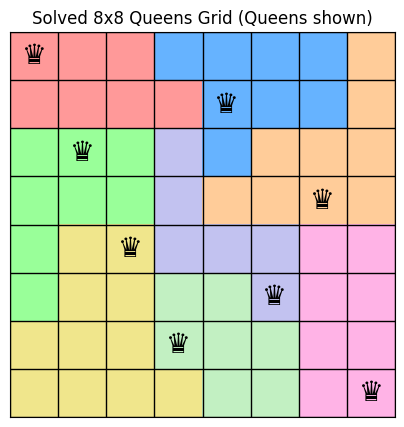

Backtracking solution (row → column): [(0, 0), (1, 4), (2, 1), (3, 6), (4, 2), (5, 5), (6, 3), (7, 7)]


In [15]:
solution8 = solve_queens_by_row_backtracking(grid8)
if solution8 is not None:
    visualize_solution_on_grid(grid8, solution8)
    print("Backtracking solution (row → column):", list(enumerate(solution8)))
else:
    print("No solution found by Backtracking.")

In [14]:
print("=== 8x8 ===")
stats8 = test_solver_accuracy(n_trials=50, grid_size=8, base_seed=100)

print("\n=== 12x12 ===")
stats12 = test_solver_accuracy(n_trials=50, grid_size=12, base_seed=200)


=== 8x8 ===
Completed 10/50 trials
Completed 20/50 trials
Completed 30/50 trials
Completed 40/50 trials
Completed 50/50 trials

Results over 50 trials:

Backtracking:
  Success: 50/50 = 100.0%
  Avg time (successful runs): 0.000092 s
  Min time (successful runs): 0.000009 s
  Max time (successful runs): 0.000795 s

MAC_FC_AC3:
  Success: 50/50 = 100.0%
  Avg time (successful runs): 0.002766 s
  Min time (successful runs): 0.001063 s
  Max time (successful runs): 0.018900 s

MinConflicts:
  Success: 33/50 =  66.0%
  Avg time (successful runs): 0.000575 s
  Min time (successful runs): 0.000166 s
  Max time (successful runs): 0.003587 s

MinConflictsRestarts:
  Success: 49/50 =  98.0%
  Avg time (successful runs): 0.097248 s
  Min time (successful runs): 0.000166 s
  Max time (successful runs): 0.796260 s

SimulatedAnnealing:
  Success: 45/50 =  90.0%
  Avg time (successful runs): 0.005362 s
  Min time (successful runs): 0.000970 s
  Max time (successful runs): 0.023378 s

=== 12x12 ===
C

# Analysis through Graphs 

## Simulated Annealing Parameter Sensitivity

Here, we analyze how temperature and cooling rate affect success probability on the 12×12 grid.

In [15]:
def test_sa_parameters_fixed_grids(grid_size=12, n_trials=30, base_seed=999):
    initial_temps = [1, 5, 20]
    cooling_rates = [0.99, 0.995, 0.999]

    # Generate grids once
    grids = []
    for i in range(n_trials):
        random.seed(base_seed + i)
        np.random.seed(base_seed + i)

        grid, _ = generate_solvable_grid_from_solution(
            grid_size=grid_size,
            n_regions=grid_size
        )
        grids.append(grid)

    print("Number of fixed grids generated:", len(grids))

    # Evaluate parameters on the same grids
    results = {}

    for T0 in initial_temps:
        for alpha in cooling_rates:
            label = f"T={T0}, α={alpha}"
            success = 0

            for grid in grids:
                sol = solve_queens_simulated_annealing(
                    grid,
                    max_steps=20000,
                    initial_temp=T0,
                    cooling_rate=alpha
                )
                if sol is not None and total_conflicts(sol, grid) == 0:
                    success += 1

            results[label] = success / len(grids)

    return results

sa_results = test_sa_parameters_fixed_grids(grid_size=12, n_trials=30)


Number of fixed grids generated: 30


## Plot SA Parameter Sensitivity Heatmap

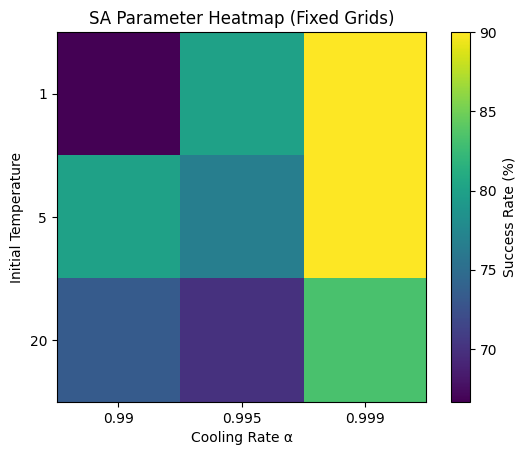

In [16]:
def plot_sa_heatmap(results):
    import matplotlib.pyplot as plt
    import numpy as np

    temps = [1, 5, 20]
    alphas = [0.99, 0.995, 0.999]

    Z = np.zeros((len(temps), len(alphas)))

    for i, T in enumerate(temps):
        for j, a in enumerate(alphas):
            key = f"T={T}, α={a}"
            Z[i, j] = results[key] * 100

    plt.figure()
    plt.imshow(Z)
    plt.colorbar(label="Success Rate (%)")
    plt.xticks(range(len(alphas)), alphas)
    plt.yticks(range(len(temps)), temps)
    plt.xlabel("Cooling Rate α")
    plt.ylabel("Initial Temperature")
    plt.title("SA Parameter Heatmap (Fixed Grids)")
    plt.show()

# Call
plot_sa_heatmap(sa_results)


## Min-Conflicts Restart Count Impact

Here, we analyze why restarts matter for Min-Conflicts by calculating the probability of success.

In [17]:
def test_restart_effect_fixed_grids(grid_size=12, n_trials=30, base_seed=777):
    restart_values = [1, 3, 5, 10, 20]

    # Generate FIXED grids once
    grids = []
    for i in range(n_trials):
        random.seed(base_seed + i)
        np.random.seed(base_seed + i)

        grid, _ = generate_solvable_grid_from_solution(
            grid_size=grid_size,
            n_regions=grid_size
        )
        grids.append(grid)

    print("Using", len(grids), "fixed grids for all restart values.")

    results = {}

    # Evaluate effect of restarts
    for restarts in restart_values:
        success = 0

        for grid in grids:
            sol = solve_with_restarts(grid, num_restarts=restarts)
            if sol is not None and total_conflicts(sol, grid) == 0:
                success += 1

        results[restarts] = 100 * success / len(grids)

    return results


Using 30 fixed grids for all restart values.


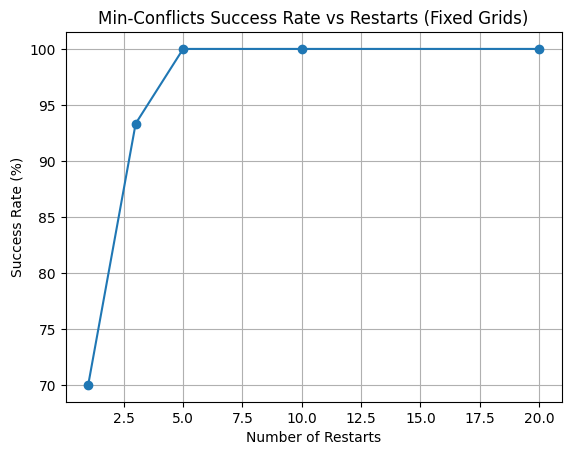

In [18]:
def plot_restart_results(results):
    import matplotlib.pyplot as plt

    x = list(results.keys())
    y = list(results.values())

    plt.figure()
    plt.plot(x, y, marker='o')
    plt.title("Min-Conflicts Success Rate vs Restarts (Fixed Grids)")
    plt.xlabel("Number of Restarts")
    plt.ylabel("Success Rate (%)")
    plt.grid(True)
    plt.show()


# Call
restart_results = test_restart_effect_fixed_grids(grid_size=12, n_trials=30)
plot_restart_results(restart_results)

## Runtime Distributions for the 4 Methods

### We first plot Runtime Histograms for each solver (having Runtime as the x-axis).
### We then plot Runtime Scatterplots for each solver (here, the x-axis is the number of trials (up to 300)).
### Lastly, we plot a vertical Boxplot to capture each solver's spread of runtime and outliers

In [19]:
def runtime_distribution_fixed_grids_separated(grid_size=12, n_trials=300, base_seed=333):
    
    # Generate fixed grids
    grids = []
    for i in range(n_trials):
        random.seed(base_seed + i)
        np.random.seed(base_seed + i)
        grid, _ = generate_solvable_grid_from_solution(
            grid_size=grid_size,
            n_regions=grid_size
        )
        grids.append(grid)

    print("Running runtime experiment on", len(grids), "fixed grids")

    solvers = {
        "Backtracking": lambda g: solve_queens_by_row_backtracking(g),
        "Min-Conflicts": lambda g: solve_queens_min_conflicts(g, 10000),
        "Simulated Annealing": lambda g: solve_queens_simulated_annealing(g, 20000, 5, 0.995),
        "Min-Conflicts + Restarts": lambda g: solve_with_restarts(g, 10)
    }

    runtime_data = {name: {"times": [], "order": []} for name in solvers}

    for name, solver in solvers.items():
        for i, grid in enumerate(grids):
            start = time.perf_counter()
            sol = solver(grid)
            elapsed = time.perf_counter() - start
            if sol is not None and total_conflicts(sol, grid) == 0:
                runtime_data[name]["times"].append(elapsed)
                runtime_data[name]["order"].append(i)

    return runtime_data


In [30]:
def plot_runtime_histograms(runtime_data):
    solvers = list(runtime_data.keys())

    # 2x2 Histogram Plot
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # square-ish layout
    axes = axes.flatten()
    
    for i, solver in enumerate(solvers):
        times = np.array(runtime_data[solver]["times"])
        if len(times) == 0: continue

        μ = mean(times)
        med = median(times)
        try:
            m = mode(times)
        except:
            m = None

        axes[i].hist(times, bins=30, color='skyblue', edgecolor='black')
        axes[i].axvline(μ, linestyle="--", color='red', label="Mean")
        axes[i].axvline(med, linestyle=":", color='green', label="Median")
        if m is not None:
            axes[i].axvline(m, linestyle="-.", color='orange', label="Mode")
        axes[i].set_title(solver)
        axes[i].set_xlabel("Runtime (s)")
        axes[i].set_ylabel("Frequency")
        axes[i].legend()
    
    plt.suptitle("Runtime Histograms per Solver", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


def plot_runtime_scatter(runtime_data):
    solvers = list(runtime_data.keys())

    # 2x2 Scatter Plot
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i, solver in enumerate(solvers):
        times = np.array(runtime_data[solver]["times"])
        order = np.array(runtime_data[solver]["order"])
        if len(times) == 0: continue

        axes[i].scatter(order, times, s=10, color='purple')
        axes[i].set_title(solver)
        axes[i].set_xlabel("Trial Index")
        axes[i].set_ylabel("Runtime (s)")
    
    plt.suptitle("Runtime Scatter per Solver (Trial Order)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


def plot_runtime_box(runtime_data):
    solvers = list(runtime_data.keys())
    fig, ax = plt.subplots(figsize=(10, 6))
    box_data = [np.array(runtime_data[solver]["times"]) for solver in solvers]
    ax.boxplot(box_data, tick_labels=solvers)
    ax.set_title("Runtime Spread & Outliers per Solver")
    ax.set_ylabel("Runtime (s)")
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.show()


Running runtime experiment on 300 fixed grids


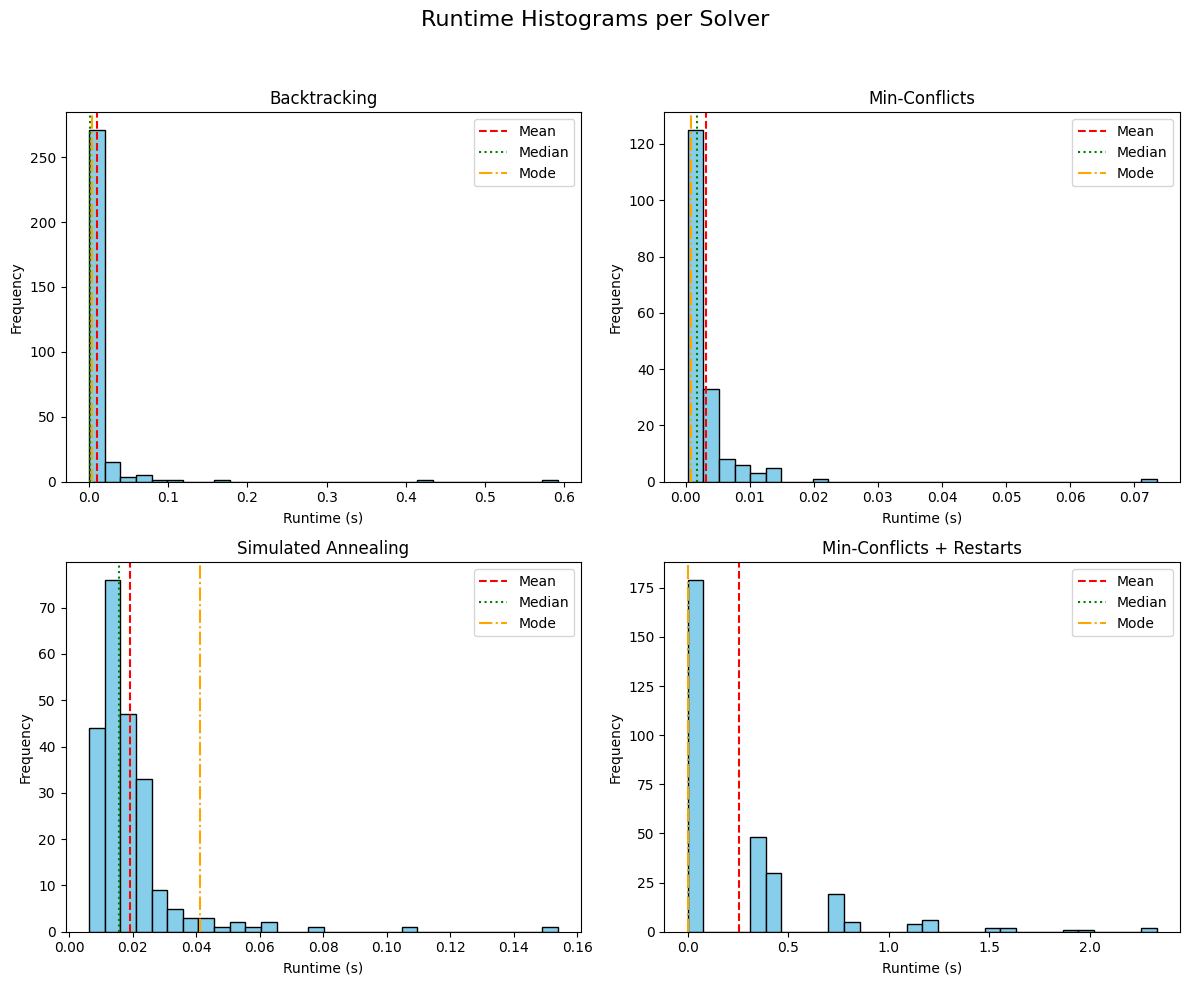

In [31]:
# Collect data
runtime_data = runtime_distribution_fixed_grids_separated(grid_size=12, n_trials=300)

# Histogram plot
plot_runtime_histograms(runtime_data)

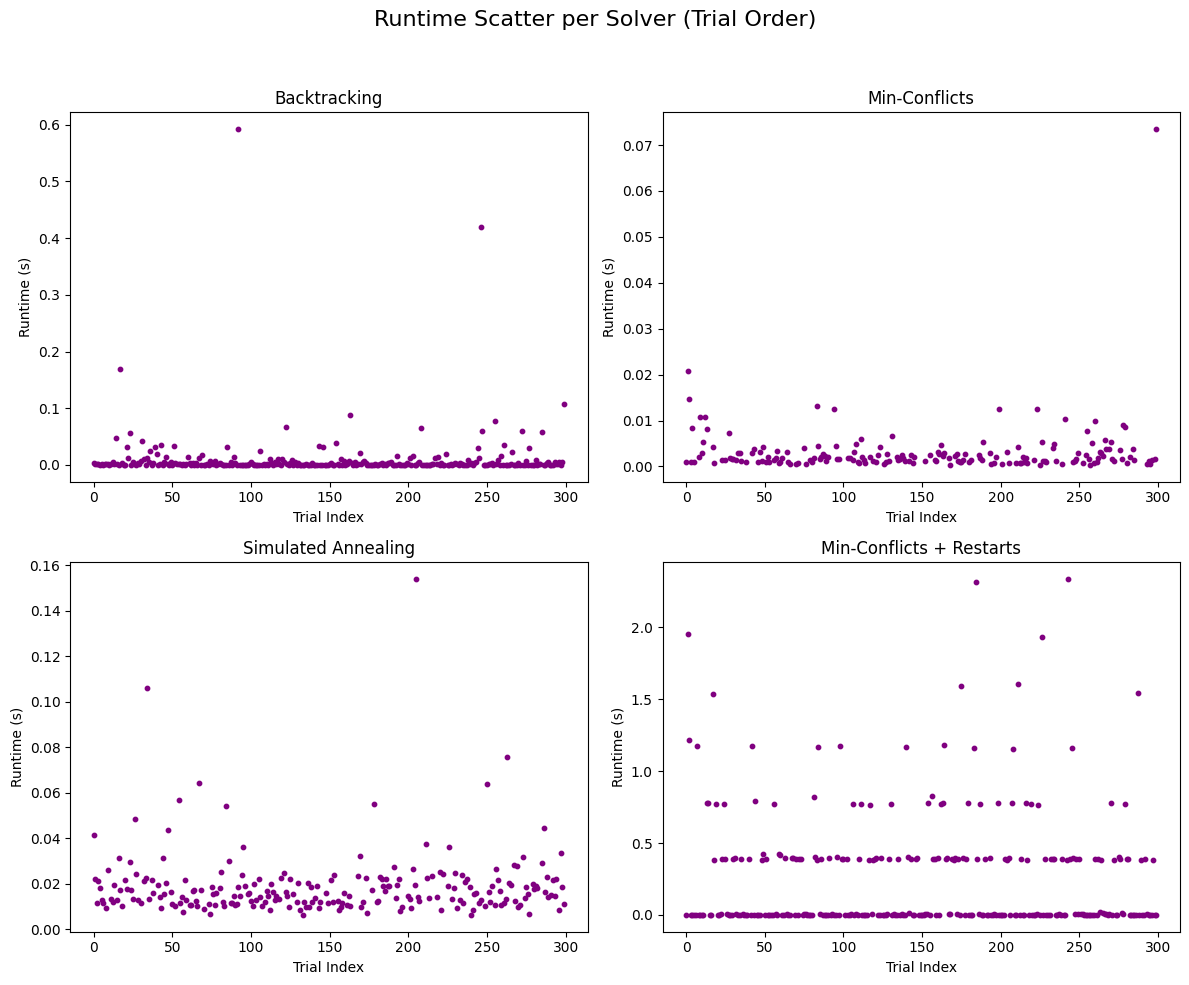

In [32]:
# Scatter plot
plot_runtime_scatter(runtime_data)

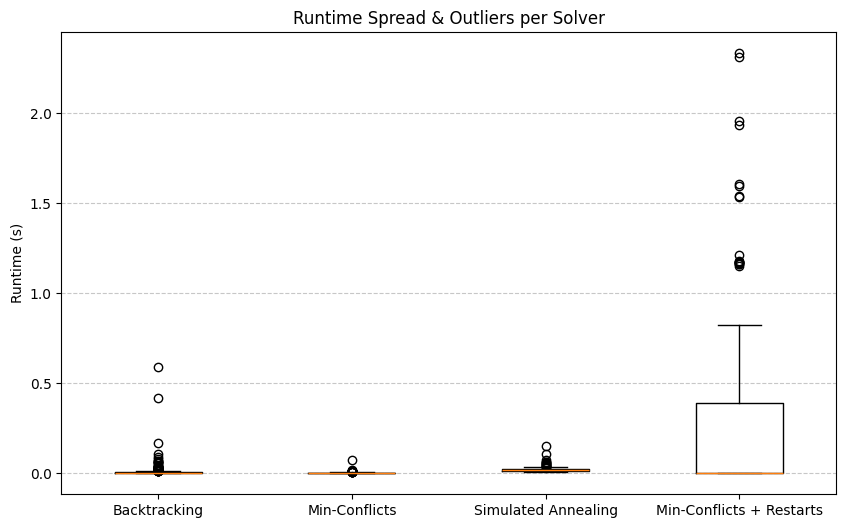

In [33]:
# Run-time Box plot
plot_runtime_box(runtime_data)

## Grid Complexity Metric Graph

### The complexity is measured by the following metrics:
1. **Region adjacency density**: number of queens in neighboring regions that could conflict (captures tightness).
2. **Initial conflict potential**: total conflicts if we randomly place one queen per row.
3. **Region distribution imbalance**: variance of the number of cells per region (how irregular the regions are).

In [22]:
def compute_grid_complexity(grid):
    n = grid.shape[0]

    # Factor 1: Random initial conflicts
    state = [random.randint(0, n-1) for _ in range(n)]
    conflicts = total_conflicts(state, grid)

    # Factor 2: adjacency density
    adj_density = 0
    for r in range(n):
        for c in range(n):
            region = grid[r, c]
            neighbors = grid[max(r-1,0):min(r+2,n), max(c-1,0):min(c+2,n)]
            adj_density += np.sum(neighbors == region) - 1  # exclude center
    adj_density /= (n**2)

    # Factor 3: region size variance
    unique, counts = np.unique(grid, return_counts=True)
    region_var = np.var(counts)

    # Combine factors
    complexity = conflicts + adj_density + region_var
    return complexity


In [23]:
# Analyze grids
def analyze_grid_complexity_vs_solver(grid_size=12, n_grids=200, base_seed=555):
    random.seed(base_seed)
    np.random.seed(base_seed)

    grids = []
    complexities = []

    for i in range(n_grids):
        grid, _ = generate_solvable_grid_from_solution(grid_size=grid_size, n_regions=grid_size)
        grids.append(grid)
        complexities.append(compute_grid_complexity(grid))

    # Solver runtimes
    solvers = {
        "Backtracking": lambda g: solve_queens_by_row_backtracking(g),
        "Min-Conflicts": lambda g: solve_queens_min_conflicts(g, max_steps=10000),
        "Simulated Annealing": lambda g: solve_queens_simulated_annealing(g, max_steps=20000)
    }

    runtime_data = {name: [] for name in solvers}
    success_data = {name: [] for name in solvers}

    for grid in grids:
        for name, solver in solvers.items():
            start = time.perf_counter()
            sol = solver(grid)
            elapsed = time.perf_counter() - start
            runtime_data[name].append(elapsed)
            if sol is not None and total_conflicts(sol, grid) == 0:
                success_data[name].append(1)
            else:
                success_data[name].append(0)

    return grids, complexities, runtime_data, success_data


In [24]:
# Plot Complexity vs. Runtime
def plot_complexity_vs_solver(complexities, runtime_data):
    solvers = list(runtime_data.keys())
    colors = ["blue", "green", "orange"]

    plt.figure(figsize=(10,5))
    for i, solver in enumerate(solvers):
        plt.scatter(complexities, runtime_data[solver], alpha=0.6, label=solver, color=colors[i])
    plt.xlabel("Grid Complexity Score")
    plt.ylabel("Solver Runtime (s)")
    plt.title("Solver Runtime vs Grid Complexity")
    plt.legend()
    plt.grid(True)
    plt.show()

In [25]:
# Plot Complexity vs. Success Rate
def plot_success_vs_complexity_binned(complexities, success_data, n_bins=10):
    solvers = list(success_data.keys())
    colors = ["blue", "green", "orange"]

    complexities = np.array(complexities)

    plt.figure(figsize=(10,6))

    for i, solver in enumerate(solvers):
        successes = np.array(success_data[solver])

        bins = np.linspace(complexities.min(), complexities.max(), n_bins+1)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        binned_success = []

        for j in range(n_bins):
            mask = (complexities >= bins[j]) & (complexities < bins[j+1])
            if np.sum(mask) > 0:
                avg_success = np.mean(successes[mask])
            else:
                avg_success = np.nan
            binned_success.append(avg_success)

        plt.plot(bin_centers, binned_success, marker='o', color=colors[i], label=solver)

    plt.xlabel("Grid Complexity Score")
    plt.ylabel("Average Solver Success Rate")
    plt.title("Solver Success vs Grid Complexity")
    plt.ylim(-0.05, 1.05)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()


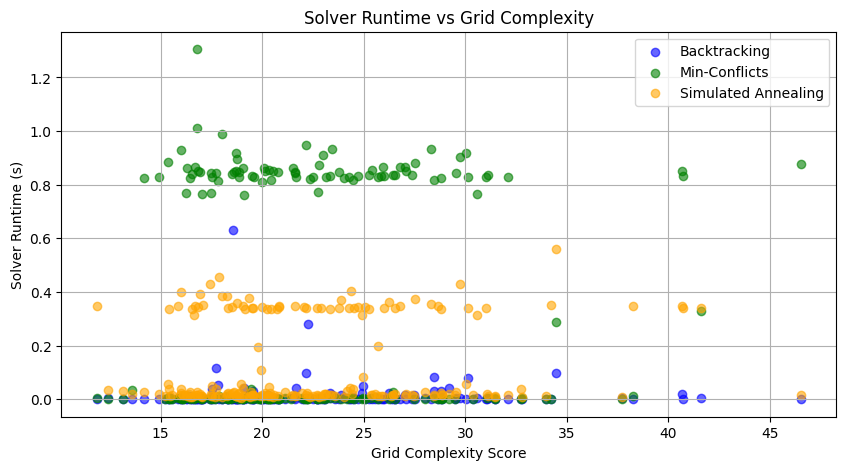

In [26]:
grids, complexities, runtime_data, success_data = analyze_grid_complexity_vs_solver(grid_size=12, n_grids=200)
plot_complexity_vs_solver(complexities, runtime_data)

In [1]:
plot_success_vs_complexity_binned(complexities, success_data, n_bins=10)


NameError: name 'plot_success_vs_complexity_binned' is not defined